#**************************************************
# FINAL PROJECT - ML, DL & NLP CAPSTONE
#**************************************************

In this project, I build a machine learning system to classify cybersecurity severity levels using text, numerical, and categorical data


### IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import precision_score, recall_score

In [4]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


=========================
# LOAD DATASET
=========================

I upload and load the dataset into a pandas DataFrame

In [91]:
df = pd.read_csv('healthcare_cybersecurity_10k.csv')
df.head()

,CVE_ID,Keyword,Published,Last_Modified,Status,Description,Severity,CVSS_Score,Attack_Vector,Weakness,Reference
0,CVE-2011-3386,medical device,2011-09-02,2025-04-11,Deferred,Unspecified vulnerability in Medtronic Paradig...,MEDIUM,4.0,NETWORK,NVD-CWE-noinfo,http://sixuntilme.com/blog2/2011/08/hacked_jay...
1,CVE-2017-12718,medical device,2018-02-15,2024-11-21,Modified,A Classic Buffer Overflow issue was discovered...,MEDIUM,6.8,NETWORK,CWE-120,http://www.securityfocus.com/bid/100665
2,CVE-2017-14002,medical device,2018-03-20,2024-11-21,Modified,GE Infinia/Infinia with Hawkeye 4 medical imag...,HIGH,10.0,NETWORK,CWE-287,http://www.securityfocus.com/bid/103405
3,CVE-2017-14006,medical device,2018-03-20,2024-11-21,Modified,"GE Xeleris versions 1.0,1.1,2.1,3.0,3.1, medic...",HIGH,7.5,NETWORK,CWE-287,https://ics-cert.us-cert.gov/advisories/ICSMA-...
4,CVE-2019-5024,medical device,2019-04-11,2024-11-21,Modified,A restricted environment escape vulnerability ...,HIGH,7.6,PHYSICAL,CWE-693,https://talosintelligence.com/vulnerability_re...


=========================
#DATA CLEANING
=========================

I clean text data to make it ready for machine learning models

In [92]:
def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

In [93]:
df["Description"] = df["Description"].apply(clean)

=========================
# DATA EXPLORATION
=========================

I explore the dataset to understand structure and missing values

In [94]:
print("Shape:", df.shape)
print(df.dtypes)
print(df.describe())
print(df.info())

Shape: (1515, 11)
CVE_ID            object
Keyword           object
Published         object
Last_Modified     object
Status            object
Description       object
Severity          object
CVSS_Score       float64
Attack_Vector     object
Weakness          object
Reference         object
dtype: object
        CVSS_Score
count  1497.000000
mean      6.554108
std       1.956064
min       1.900000
25%       5.400000
50%       6.500000
75%       7.600000
max      10.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CVE_ID         1515 non-null   object 
 1   Keyword        1515 non-null   object 
 2   Published      1515 non-null   object 
 3   Last_Modified  1515 non-null   object 
 4   Status         1515 non-null   object 
 5   Description    1515 non-null   object 
 6   Severity       1497 non-null   object 
 7   CVSS_Score    

In [95]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass balance:")
print(df["Severity"].value_counts())

print("\nClass balance (percentage):")
print(df["Severity"].value_counts(normalize=True))


Missing values:
CVE_ID            0
Keyword           0
Published         0
Last_Modified     0
Status            0
Description       0
Severity         18
CVSS_Score       18
Attack_Vector    18
Weakness          1
Reference         0
dtype: int64

Class balance:
Severity
MEDIUM      720
HIGH        492
CRITICAL    151
LOW         134
Name: count, dtype: int64

Class balance (percentage):
Severity
MEDIUM      0.480962
HIGH        0.328657
CRITICAL    0.100868
LOW         0.089512
Name: proportion, dtype: float64


=========================
# MISSING VALUES HANDLING
=========================

I fill missing values in categorical columns

In [96]:
df["Weakness"] = df["Weakness"].fillna("Unknown")

In [97]:
df = df.dropna(subset=["Severity"])

df["CVSS_Score"] = df["CVSS_Score"].fillna(df["CVSS_Score"].median())
df["Attack_Vector"] = df["Attack_Vector"].fillna("Unknown")
df["Weakness"] = df["Weakness"].fillna("Unknown")

=========================
# FEATURES & TARGET
=========================

I split data into input features X and target label y

In [98]:
X = df[["Description", "CVSS_Score", "Attack_Vector", "Weakness"]]
y = df["Severity"]

=========================
# TRAIN-TEST SPLIT
=========================

I split the dataset into training and testing sets

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

=========================
# PREPROCESSING PIPELINE
=========================

I convert text categorical and numeric data into numerical format

In [100]:
preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=5000), "Description"),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["Attack_Vector", "Weakness"]),
    ("num", "passthrough", ["CVSS_Score"])
])

=========================
# MACHINE LEARNING MODELS
=========================

I train and compare 3 different ML models

In [101]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


********************
Logistic Regression
              precision    recall  f1-score   support

    CRITICAL       0.93      0.90      0.92        30
        HIGH       0.97      0.98      0.97        99
         LOW       1.00      0.93      0.96        27
      MEDIUM       0.99      1.00      0.99       144

    accuracy                           0.98       300
   macro avg       0.97      0.95      0.96       300
weighted avg       0.98      0.98      0.98       300



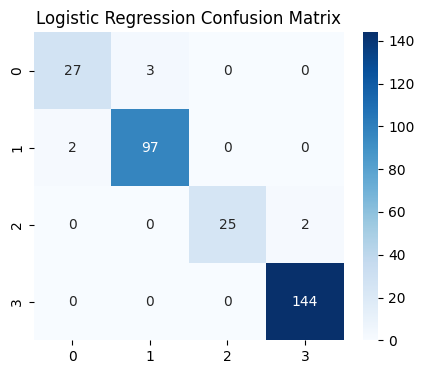


********************
Random Forest
              precision    recall  f1-score   support

    CRITICAL       0.95      0.67      0.78        30
        HIGH       0.85      0.87      0.86        99
         LOW       0.74      0.63      0.68        27
      MEDIUM       0.85      0.92      0.88       144

    accuracy                           0.85       300
   macro avg       0.85      0.77      0.80       300
weighted avg       0.85      0.85      0.85       300



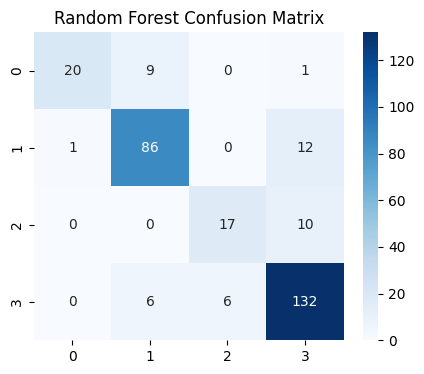


********************
KNN
              precision    recall  f1-score   support

    CRITICAL       0.91      0.97      0.94        30
        HIGH       0.94      0.96      0.95        99
         LOW       0.89      0.93      0.91        27
      MEDIUM       0.98      0.94      0.96       144

    accuracy                           0.95       300
   macro avg       0.93      0.95      0.94       300
weighted avg       0.95      0.95      0.95       300



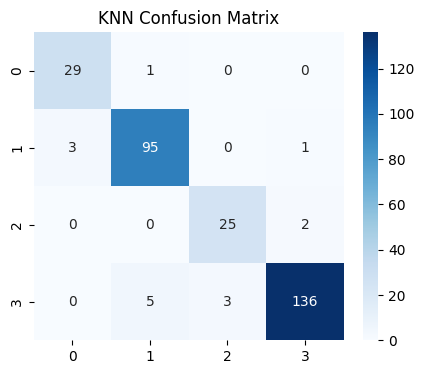

In [102]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted")
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

    print("\n********************")
    print(name)
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

=========================
# RESULTS TABLE
=========================

I compare all ML models using evaluation metrics

In [103]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.976667,0.976628,0.976667,0.976462
1,Random Forest,0.850000,0.851524,0.850000,0.847244
2,KNN,0.950000,0.951018,0.950000,0.950209


In [104]:
print(results_df.sort_values("F1", ascending=False))

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.976667   0.976628  0.976667  0.976462
2                  KNN  0.950000   0.951018  0.950000  0.950209
1        Random Forest  0.850000   0.851524  0.850000  0.847244


=========================
# LABEL ENCODING (NEURAL NETWORK)
=========================

I convert labels into numbers for neural network training

In [105]:
le = LabelEncoder()
y_train_nn = le.fit_transform(y_train)
y_test_nn = le.transform(y_test)

=========================
# NEURAL NETWORK PREPROCESSING
=========================

I reuse preprocessing and convert data into numerical arrays

In [106]:
nn_preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=5000), "Description"),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["Attack_Vector", "Weakness"]),
    ("num", "passthrough", ["CVSS_Score"])
])

X_train_nn = nn_preprocessor.fit_transform(X_train).toarray()
X_test_nn = nn_preprocessor.transform(X_test).toarray()

=========================
# BUILD NEURAL NETWORK
=========================

I create a deep learning model using Dense layers

In [107]:
model = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train_nn.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(np.unique(y_train_nn)), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=========================
# TRAIN NEURAL NETWORK
=========================

I train the model and validate performance

In [108]:
history = model.fit(
    X_train_nn, y_train_nn,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.4765 - loss: 1.1906 - val_accuracy: 0.5625 - val_loss: 1.0855
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5904 - loss: 1.0122 - val_accuracy: 0.6458 - val_loss: 0.9120
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6813 - loss: 0.8141 - val_accuracy: 0.6417 - val_loss: 0.7560
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7806 - loss: 0.6215 - val_accuracy: 0.7292 - val_loss: 0.6054
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8359 - loss: 0.4426 - val_accuracy: 0.8208 - val_loss: 0.4962
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8757 - loss: 0.3578 - val_accuracy: 0.8333 - val_loss: 0.4686
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9070 - loss: 0.2662 - val_accuracy: 0.8042 - val_loss: 0.4575
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9415 - loss: 0.2040 - val_accuracy: 0.8375 - v

=========================
# TRAINING CURVES
=========================

I plot accuracy and loss to check overfitting

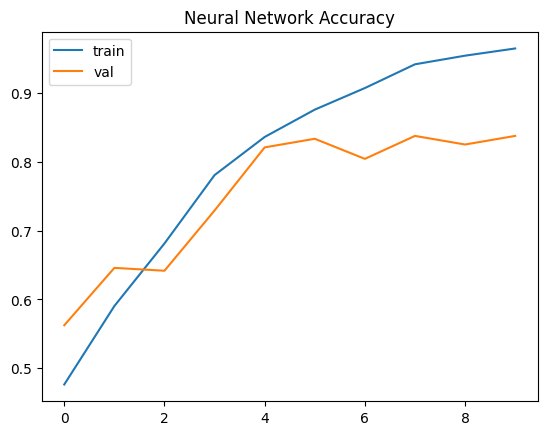

In [109]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Neural Network Accuracy")
plt.legend()
plt.show()

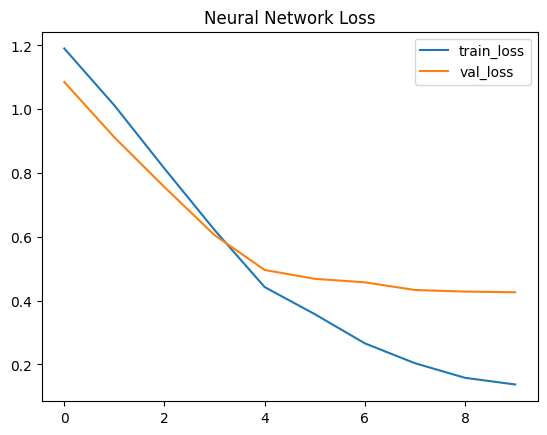

In [110]:
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Neural Network Loss")
plt.legend()
plt.show()

=========================
# MODEL EVALUATION
=========================

I evaluate neural network performance

In [111]:
loss, acc = model.evaluate(X_test_nn, y_test_nn)
print("NN Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8333 - loss: 0.4655 
NN Accuracy: 0.8333333134651184


In [112]:
nn_preds = model.predict(X_test_nn).argmax(axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


I add results to comparison table

In [113]:
results_df.loc[len(results_df)] = [
    "Neural Network",
    accuracy_score(y_test_nn, nn_preds),
    precision_score(y_test_nn, nn_preds, average="weighted"),
    recall_score(y_test_nn, nn_preds, average="weighted"),
    f1_score(y_test_nn, nn_preds, average="weighted")
]

=========================
# FINAL COMPARISON
=========================

In [114]:
print("FINAL COMPARISON TABLE:")
print(results_df.sort_values("F1", ascending=False))

FINAL COMPARISON TABLE:
                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.976667   0.976628  0.976667  0.976462
2                  KNN  0.950000   0.951018  0.950000  0.950209
1        Random Forest  0.850000   0.851524  0.850000  0.847244
3       Neural Network  0.833333   0.846156  0.833333  0.825438
